# Model Building

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys; sys.path.insert(0, "..")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

from src.data_preparation import load_and_prepare, get_feature_target_split
from src.model import build_pipeline, churn_prediction, get_optimal_threshold, BEST_PARAMS

%matplotlib inline
sns.set_style("darkgrid")

### 1. Load & Split Data

In [3]:
df, encoder = load_and_prepare(
    "../data/E Commerce Dataset.xlsx",
    is_excel=True,
    sheet_name="E Comm",
    fit_encoder=True,
)
X, y = get_feature_target_split(df)
feature_names = X.columns.tolist()

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
print(f"Train: {x_train.shape} | Test: {x_test.shape}")
print(f"Churn rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Train: (4222, 17) | Test: (1408, 17)
Churn rate — Train: 0.168 | Test: 0.168


Stratified split preserves the ~17% churn ratio in both sets.

### 2. Pipeline

In [ ]:
# The pipeline chains median imputation -> RandomForestClassifier for imputer to fit inside each CV fold
pipeline = build_pipeline()
print(pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight={0: 1, 1: 3.4},
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=20,
                                        min_samples_split=30,
                                        min_weight_fraction_leaf=0,
                                        n_estimators=1000, n_jobs=-1,
                                        random_state=42))])


### 3. Cross-Validation Baseline

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# AUC is more robust than F1 for imbalanced data in CV
# because it does not depend on a fixed probability threshold
cv_scores = cross_val_score(pipeline, x_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"CV AUC per fold: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")

CV AUC per fold: [0.8945 0.8747 0.8798 0.8626 0.8465]
Mean: 0.8716  Std: 0.0162


### 4. Train and Evaluate

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight={0: 1, 1: 3.4},
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=20,
                                        min_samples_split=30,
                                        min_weight_fraction_leaf=0,
                                        n_estimators=1000, n_jobs=-1,
                                        random_state=42))])

Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      1171
           1       0.55      0.62      0.58       237

    accuracy                           0.85      1408
   macro avg       0.73      0.76      0.74      1408
weighted avg       0.86      0.85      0.85      1408

Test Accuracy Score: 0.8494318181818182
--------------------------------------------------

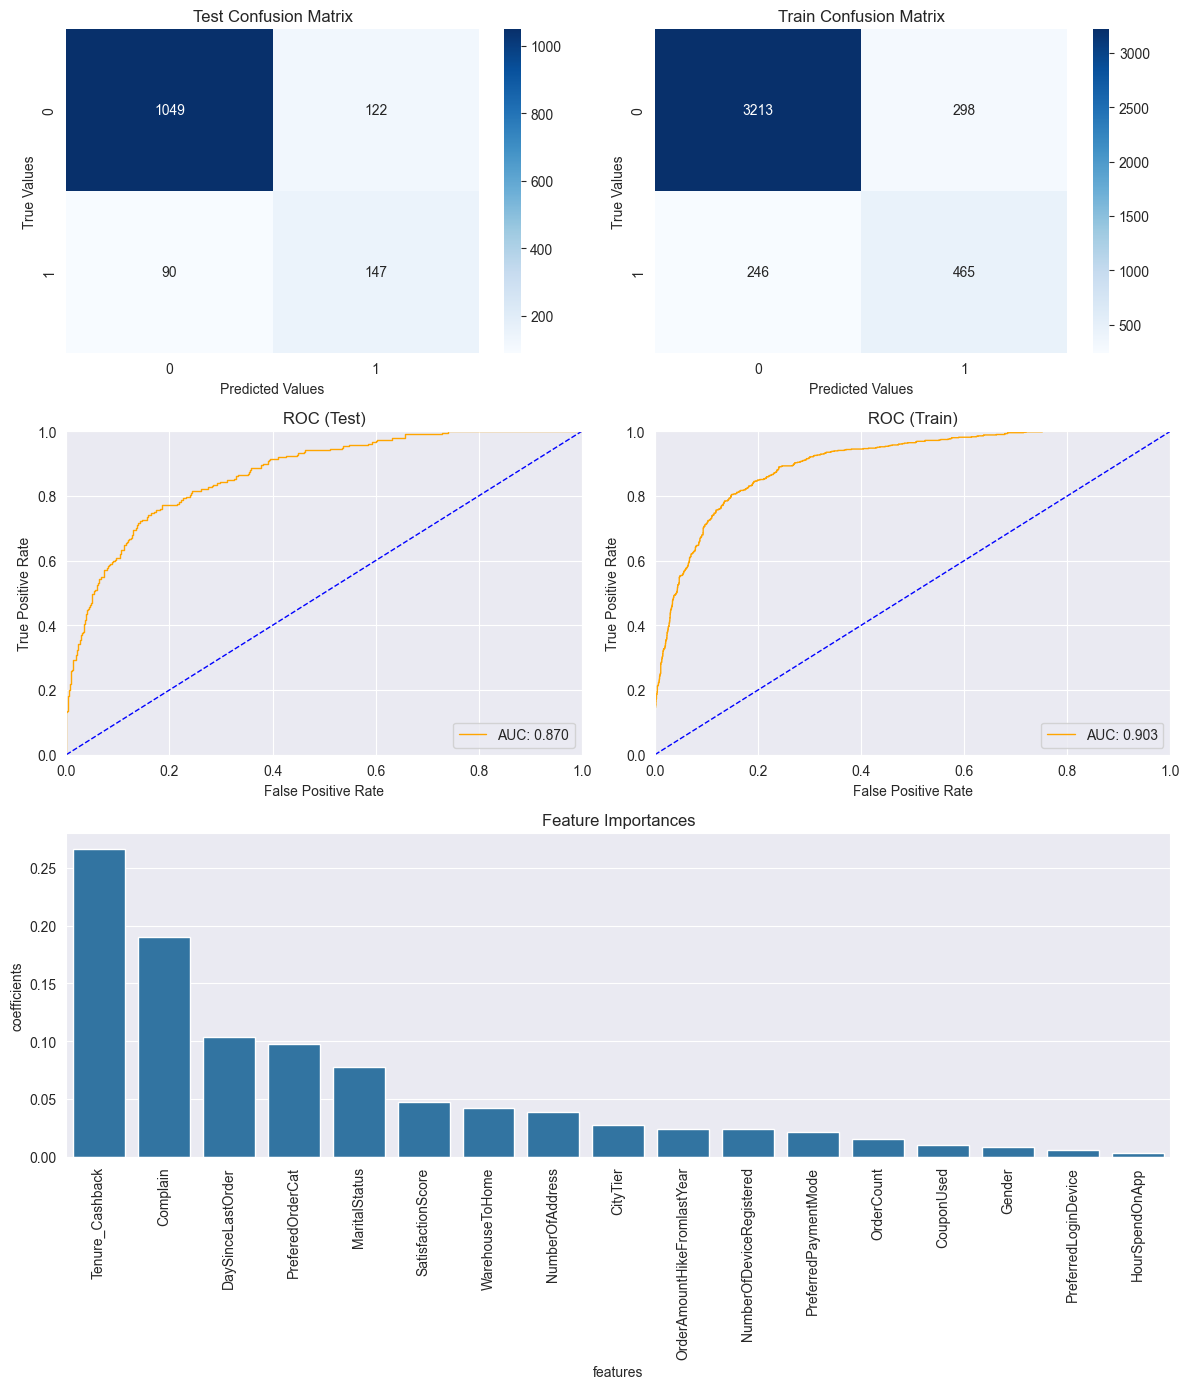

In [6]:
churn_prediction(build_pipeline(), x_train, x_test, y_train, y_test, feature_names, cf="features")

### 5. Overfitting Diagnosis

A healthy model should have a **small gap** between training and test AUC (ideally < 0.03). A training AUC near 1.0 with any notable test drop indicates memorisation.

In [8]:
final = build_pipeline()
final.fit(x_train, y_train)

train_auc = roc_auc_score(y_train, final.predict_proba(x_train)[:, 1])
test_auc  = roc_auc_score(y_test,  final.predict_proba(x_test)[:, 1])

print(f"Train AUC: {train_auc:.4f}")
print(f" Test AUC: {test_auc:.4f}")
print(f"      Gap: {train_auc - test_auc:.4f}  (target: < 0.030)")

Train AUC: 0.9032
 Test AUC: 0.8704
      Gap: 0.0328  (target: < 0.030)


### 6. Threshold Optimisation

In [9]:
# For finding threshold that maximizes f1 as default 0.5 threshold is not usually optimal for imbalanced data
threshold = get_optimal_threshold(final, x_test, y_test)

probs = final.predict_proba(x_test)[:, 1]
preds = (probs >= threshold).astype(int)
print(classification_report(y_test, preds))

Optimal threshold: 0.4526  |  F1: 0.5965
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1171
           1       0.51      0.72      0.60       237

    accuracy                           0.84      1408
   macro avg       0.72      0.79      0.75      1408
weighted avg       0.87      0.84      0.85      1408



### 7. Save findings

Run `python scripts/train.py` to train and dump the model to `models/` for the API.